# Case Study 2 - Titanic Dataset
 Aicha Dieng

# Business Case and Target Variable

This project uses the **Titanic dataset**, which contains information on **891 passengers** and **15 variables ** describing their demographics and travel conditions. The business goal of this analysis is to **predict whether a passenger survived the Titanic disaster** based on key characteristics such as **age**, **gender**, **class**, **family relationships onboard** etc.

This type of prediction reflects the kind of information **families** and **authorities** would have needed at the time to determine the fate of missing relatives. The target variable in this study is the **“survived”** column, which indicates whether a passenger survived or not.

 By modeling survival, this project demonstrates how machine learning can be applied to real-world historical data to understand patterns of human survival in crisis situations like the Titanic.

In [850]:
import seaborn as sns

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

In [851]:
# Print the first few rows of the dataset
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [852]:
titanic.shape

(891, 15)

891 rows, 15 rows

# Missing Values

In [853]:
titanic.isna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [854]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Missing values in age (177), embarked (2) , embark_town (2), deck (698).


/tmp/ipython-input-1002111337.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='viridis')


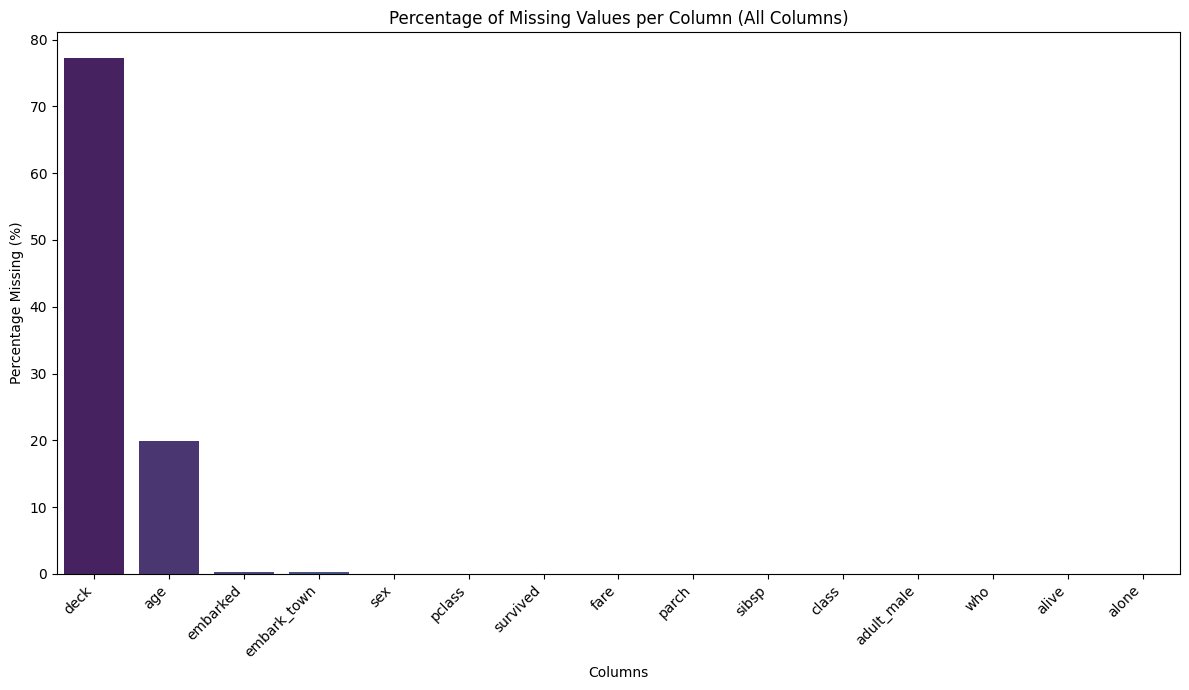

In [855]:
import matplotlib.pyplot as plt

# Calculate the percentage of missing values for all columns
missing_percentage = titanic.isnull().sum() / len(titanic) * 100

# Sort values for better visualization
missing_percentage = missing_percentage.sort_values(ascending=False)

# Create the plot including all columns
plt.figure(figsize=(12, 7))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='viridis')
plt.title('Percentage of Missing Values per Column (All Columns)')
plt.xlabel('Columns')
plt.ylabel('Percentage Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [856]:
titanic = titanic.drop('deck', axis=1)
print("Colonne 'deck' supprimée.")
titanic.head()

Colonne 'deck' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


#### Dropping columns

In [857]:
titanic = titanic.drop('who', axis=1)
print("Colonne 'who' supprimée.")
titanic.head()

Colonne 'who' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,no,True


In [858]:
titanic = titanic.drop('class', axis=1)
print("Colonne 'class' supprimée.")
titanic.head()

Colonne 'class' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,True,Southampton,no,True


In [859]:
titanic = titanic.drop('adult_male', axis=1)
print("Colonne 'adult_male' supprimée.")
titanic.head()

Colonne 'adult_male' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Southampton,no,True


In [860]:
titanic = titanic.drop('embarked', axis=1)
print("Colonne 'embarked' supprimée.")
titanic.head()

Colonne 'embarked' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Southampton,no,True


In [861]:
titanic = titanic.drop('alive', axis=1)
print("Colonne 'alive' supprimée.")
titanic.head()

Colonne 'alive' supprimée.


,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Southampton,True
3,1,1,female,35.0,1,0,53.1000,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Southampton,True


In [862]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False


In total, my dataset contains **891 rows** and **15 columns**, which means I am working with 891 **passengers** and 15 **different** **characteristics** describing them. When I checked for missing values, I found that the **deck** column had **688** **missing** **entries**, which is more than **75% **of that column, so it was not reliable enough to keep. **Age** also had around **20%** missing values, and both **embarked** and **embark_town** had **2** missing values each, and they referred to the **same** **information** about where the passenger boarded the ship.

 Some columns had to be dropped. I removed the **deck** because of the high amount of missing data, and I also dropped columns that were **redundant**, meaning they were giving me the same information as another variable. For example, **who** was already covered by sex, **class** was the same information as pclass (ticket class), **adult_male** was related to sex and age, **embarked** duplicated embark_town, and **alive** was the same outcome as survived.

#### Encoding features

In [863]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False


In [864]:
import pandas as pd

# Create a copy of the original titanic_copy for this demonstration
titanic_survived_encoded = titanic.copy()

# One-hot encode 'survived' without dropping the first category
survived_encoded = pd.get_dummies(titanic_survived_encoded['survived'], prefix='survived', drop_first=False)

# Display the first few rows of the new encoded columns
display(survived_encoded.head())

print("Here, 'survived_0' indicates 'not survived' and 'survived_1' indicates 'survived'.")
print("Each column is independent, explicitly showing the state without implying numerical order between the categories themselves.")

,survived_0,survived_1
0,True,False
1,False,True
2,False,True
3,False,True
4,True,False


Here, 'survived_0' indicates 'not survived' and 'survived_1' indicates 'survived'.
Each column is independent, explicitly showing the state without implying numerical order between the categories themselves.


In [865]:
import pandas as pd

# One-hot encode 'pclass' without dropping the first category
pclass_encoded = pd.get_dummies(titanic['pclass'], prefix='pclass', drop_first=False)

# Display the first few rows of the new encoded columns
display(pclass_encoded.head())

print("Here, 'pclass_1' indicates 1st class, 'pclass_2' indicates 2nd class, and 'pclass_3' indicates 3rd class.")
print("Each column is independent, explicitly showing the presence of a class without implying numerical order between them.")

,pclass_1,pclass_2,pclass_3
0,False,False,True
1,True,False,False
2,False,False,True
3,True,False,False
4,False,False,True


Here, 'pclass_1' indicates 1st class, 'pclass_2' indicates 2nd class, and 'pclass_3' indicates 3rd class.
Each column is independent, explicitly showing the presence of a class without implying numerical order between them.


In [866]:
import pandas as pd

# One-hot encode 'sex' without dropping the first category
sex_encoded = pd.get_dummies(titanic['sex'], prefix='sex', drop_first=False)

# Rename columns to be more descriptive (assuming 0 is male, 1 is female)
# Check the current column names generated by get_dummies first
# print(sex_encoded.columns) # Uncomment to verify generated column names
sex_encoded.rename(columns={'sex_0': 'sex_men', 'sex_1': 'sex_women'}, inplace=True)

# Display the first few rows of the new encoded columns
display(sex_encoded.head())

print("Here, 'sex_men' indicates male and 'sex_women' indicates female.")
print("Each column is independent, explicitly showing the state without implying numerical order.")

,sex_female,sex_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


Here, 'sex_men' indicates male and 'sex_women' indicates female.
Each column is independent, explicitly showing the state without implying numerical order.


In [867]:
import pandas as pd

# One-hot encode 'embark_town' without dropping the first category
embark_town_encoded = pd.get_dummies(titanic['embark_town'], prefix='embark_town', drop_first=False)

# Display the first few rows of the new encoded columns
display(embark_town_encoded.head())

print("Here, each column (embark_town_Cherbourg, embark_town_Queenstown, embark_town_Southampton) indicates the presence of that specific embarkation town.")
print("Each column is independent, explicitly showing the state without implying numerical order.")

,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


Here, each column (embark_town_Cherbourg, embark_town_Queenstown, embark_town_Southampton) indicates the presence of that specific embarkation town.
Each column is independent, explicitly showing the state without implying numerical order.


In [868]:
import pandas as pd

# One-hot encode 'alone' without dropping the first category
alone_encoded = pd.get_dummies(titanic['alone'], prefix='alone', drop_first=False)

# Rename columns to be more descriptive (assuming False was 0 and True was 1)
alone_encoded.rename(columns={'alone_False': 'alone_not_alone', 'alone_True': 'alone_is_alone'}, inplace=True)

# Display the first few rows of the new encoded columns
display(alone_encoded.head())

print("Here, 'alone_not_alone' indicates the passenger was not alone, and 'alone_is_alone' indicates the passenger was alone.")
print("Each column is independent, explicitly showing the state without implying numerical order.")

,alone_not_alone,alone_is_alone
0,True,False
1,True,False
2,False,True
3,True,False
4,False,True


Here, 'alone_not_alone' indicates the passenger was not alone, and 'alone_is_alone' indicates the passenger was alone.
Each column is independent, explicitly showing the state without implying numerical order.


In [869]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False


In [870]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [871]:
titanic.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embark_town,object
alone,bool


After cleaning the data, the next step was **encoding** several columns so they could be properly used by the models. For example, the **survived** column was converted into 0s and 1s, since the computer *cannot interpret text like* **“survived”** or “**not survived**,” and it works much better with **numerical values**. The same process was applied to **pclass**, **sex**, and **embark_town**, which were all transformed into encoded variables so the model could understand **class level**, **gender**, and where passengers **embarked** from. Whether a passenger was traveling **alone** or not was also encoded in the same way. After encoding, the data types were checked to make sure every variable was correctly formatted and fully ready for modeling.


# EDA - Exploratory Data Analysis

## Univariate Analysis

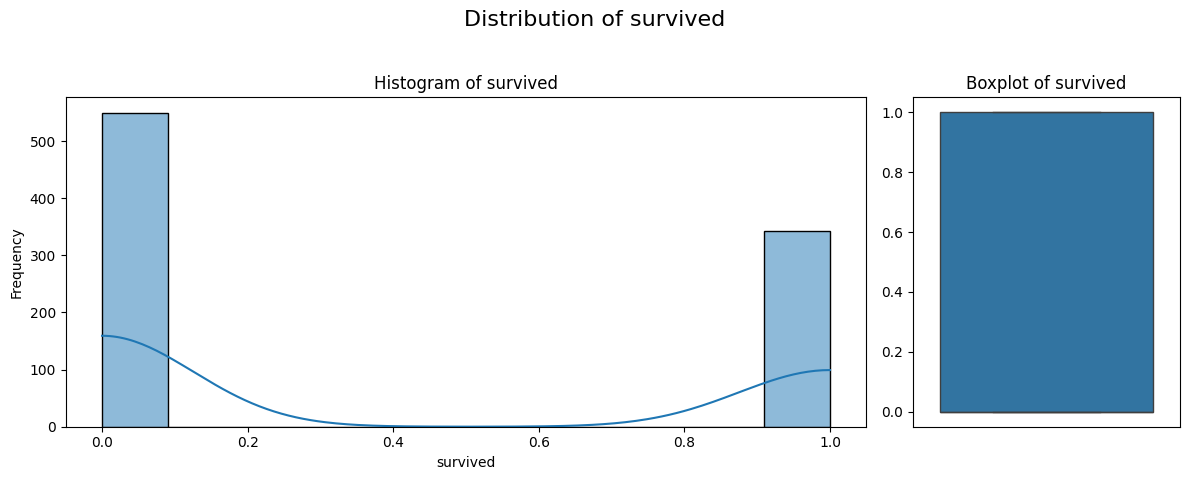

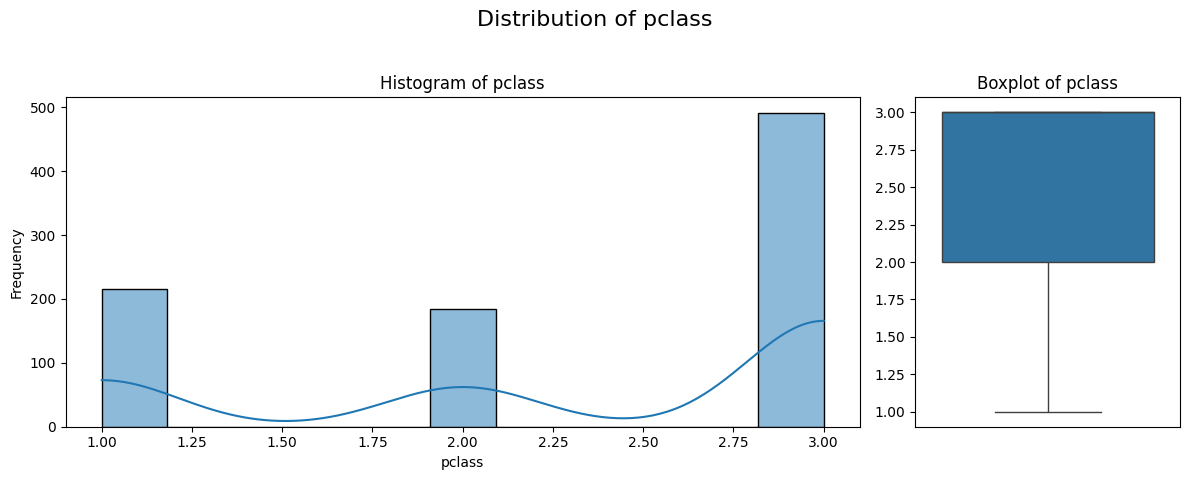

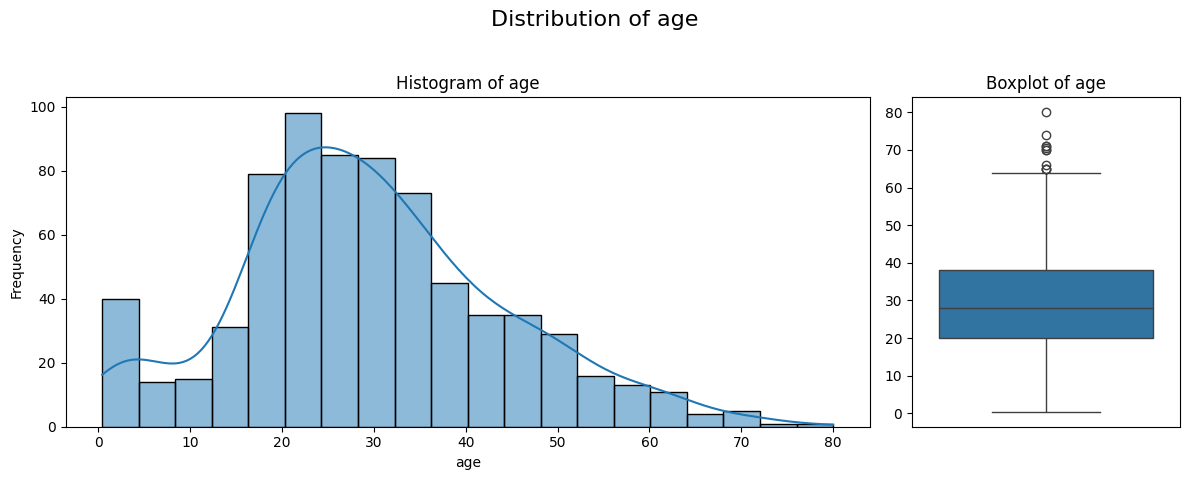

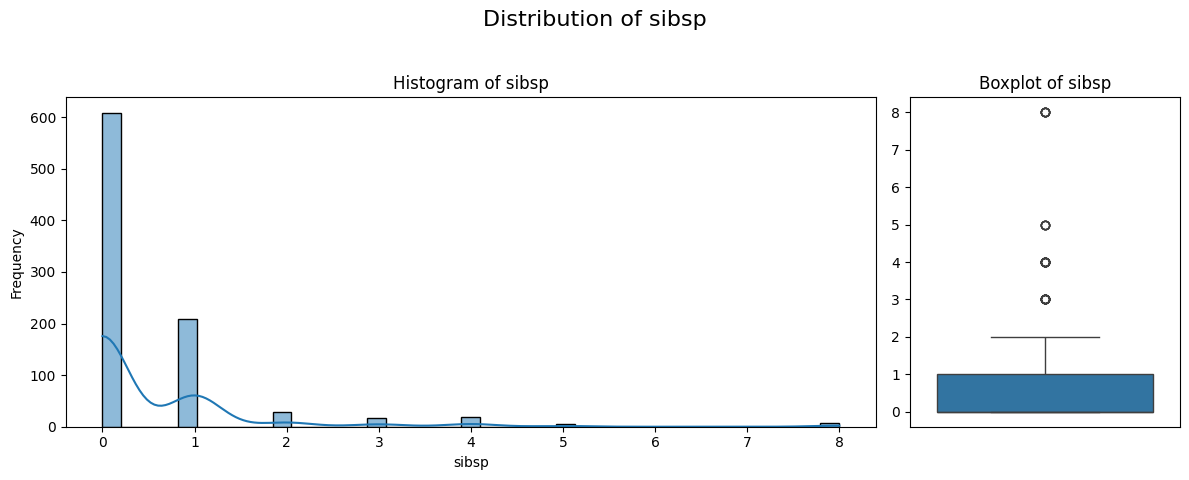

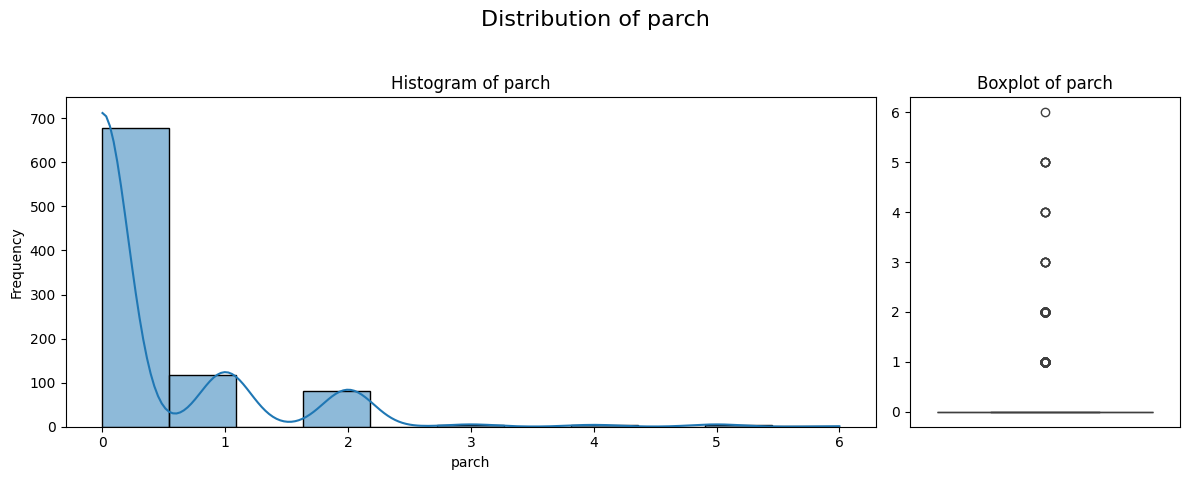

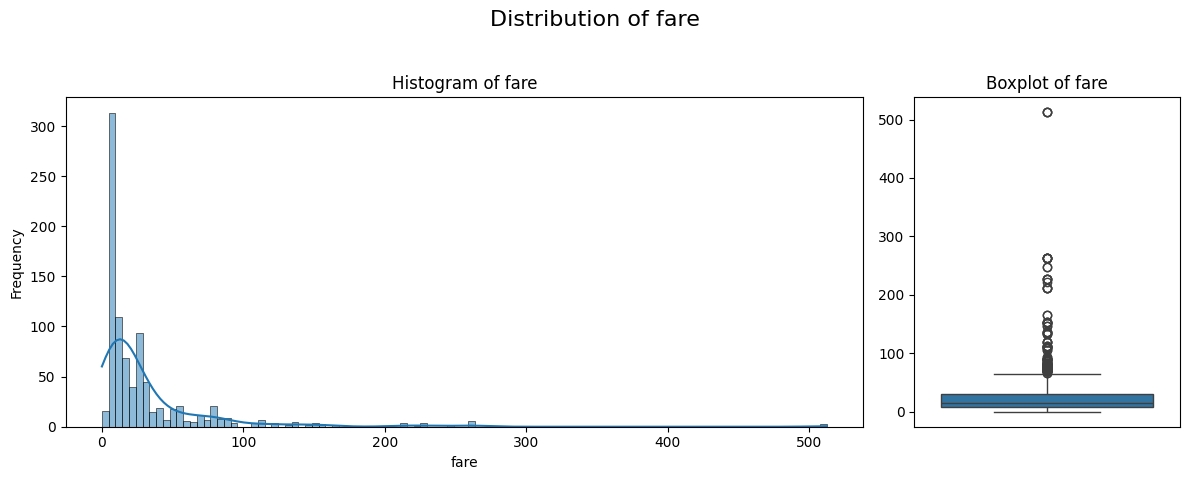

In [872]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = titanic.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    # Create a figure with two subplots: one for histogram, one for boxplot
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

    # Plot histogram on the left subplot
    sns.histplot(titanic[col], kde=True, ax=ax_hist)
    ax_hist.set_title(f'Histogram of {col}')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frequency')

    # Plot boxplot on the right subplot
    sns.boxplot(y=titanic[col], ax=ax_box)
    ax_box.set_title(f'Boxplot of {col}')
    ax_box.set_ylabel('') # Remove y-label as it's redundant with histogram's x-axis
    ax_box.set_xticks([]) # Remove x-ticks for a single vertical boxplot

    plt.suptitle(f'Distribution of {col}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

In [873]:
titanic_copy = titanic.copy()
median_age_copy = titanic_copy['age'].median()
titanic_copy['age'].fillna(median_age_copy, inplace=True)

print(f"Missing values in 'age' column of titanic_copy imputed with median: {median_age_copy}")
titanic_copy.info()

Missing values in 'age' column of titanic_copy imputed with median: 28.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


/tmp/ipython-input-3578772619.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_copy['age'].fillna(median_age_copy, inplace=True)


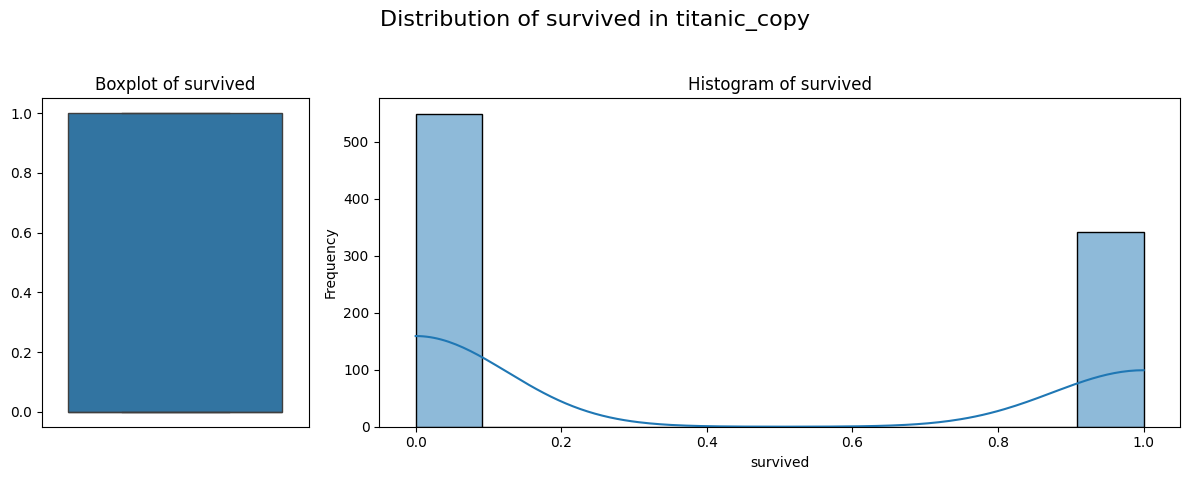

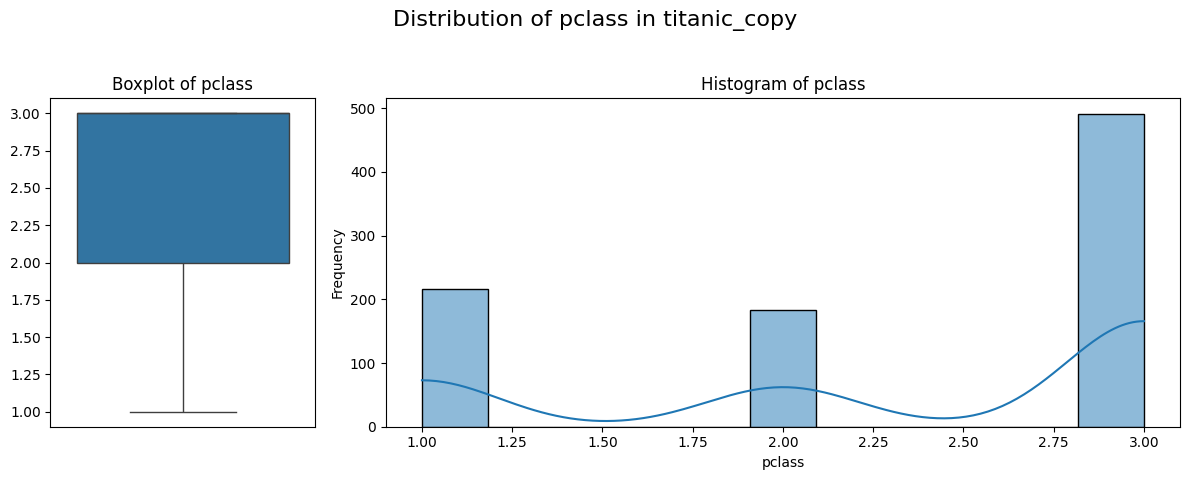

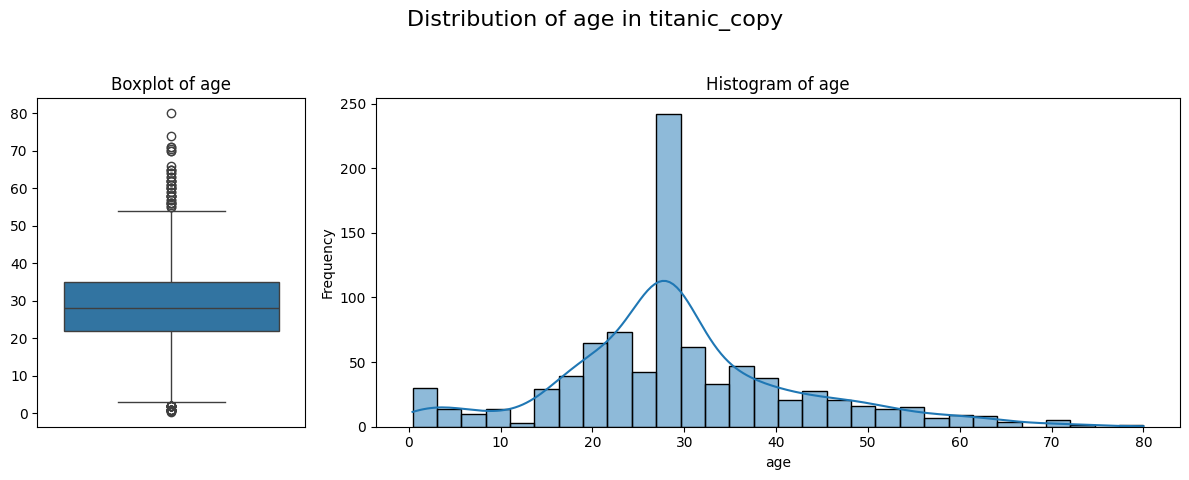

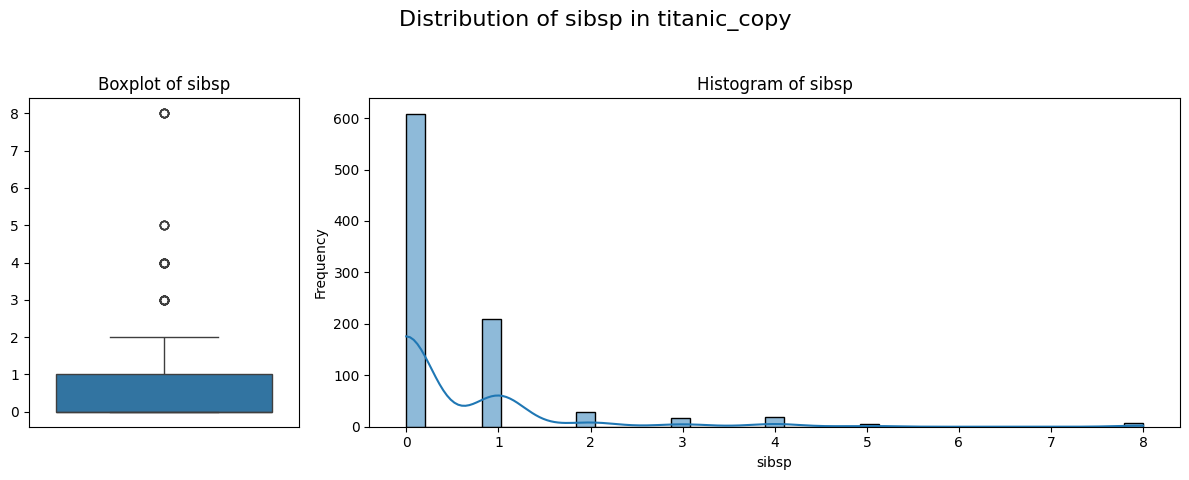

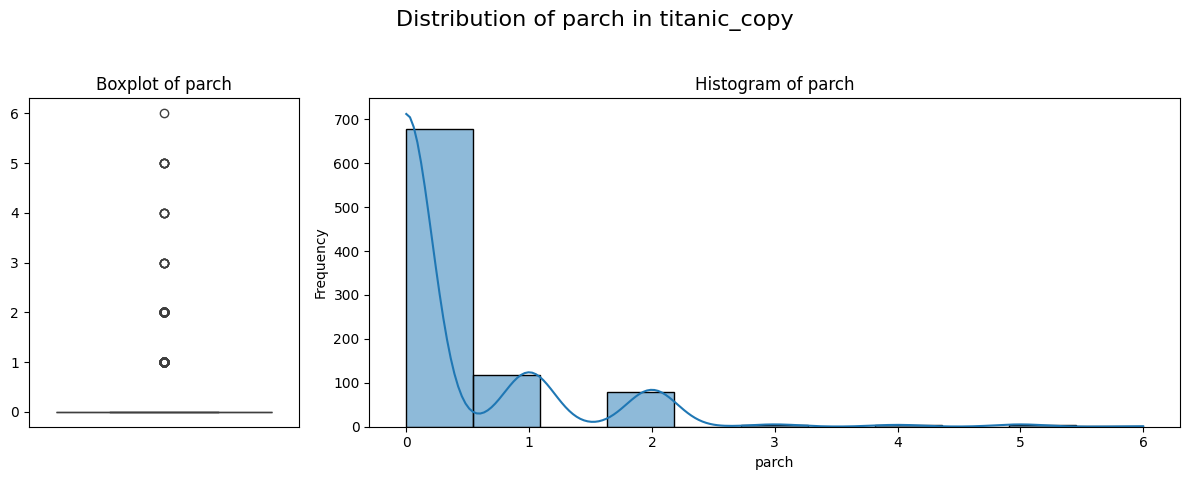

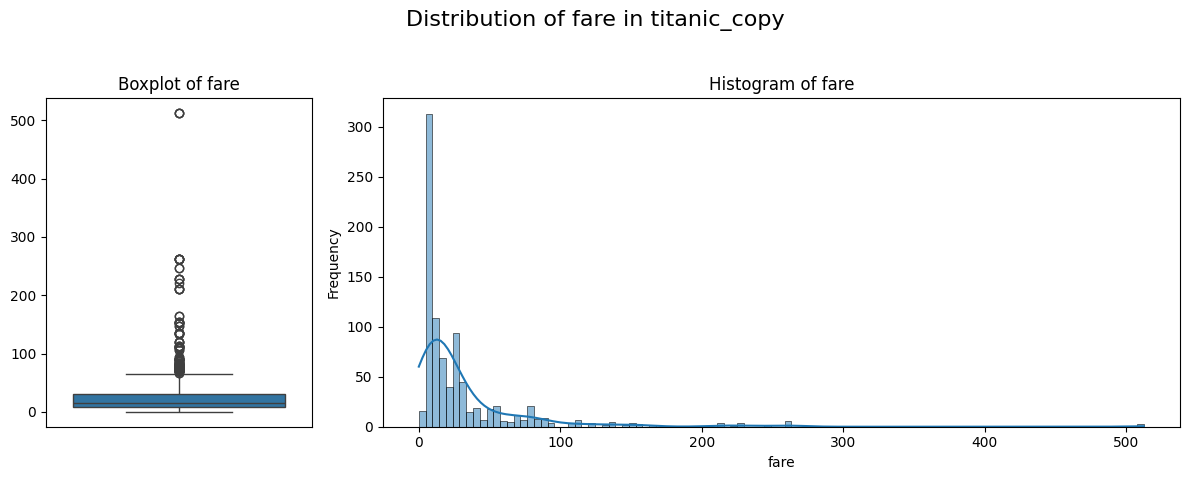

In [874]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from titanic_copy
numerical_cols_copy = titanic_copy.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols_copy:
    # Create a figure with two subplots: one for boxplot, one for histogram
    # Set width_ratios to place boxplot on the left (ratio 1) and histogram on the right (ratio 3)
    fig, (ax_box, ax_hist) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 3]})

    # Plot boxplot on the left subplot
    sns.boxplot(y=titanic_copy[col], ax=ax_box)
    ax_box.set_title(f'Boxplot of {col}')
    ax_box.set_ylabel('') # Remove y-label as it's redundant with histogram's x-axis
    ax_box.set_xticks([]) # Remove x-ticks for a single vertical boxplot

    # Plot histogram on the right subplot
    sns.histplot(titanic_copy[col], kde=True, ax=ax_hist)
    ax_hist.set_title(f'Histogram of {col}')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frequency')

    plt.suptitle(f'Distribution of {col} in titanic_copy', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

In [875]:
mode_embark_town = titanic_copy['embark_town'].mode()[0]
titanic_copy['embark_town'].fillna(mode_embark_town, inplace=True)

print(f"Missing values in 'embark_town' column imputed with mode: {mode_embark_town}")
titanic_copy.info()

Missing values in 'embark_town' column imputed with mode: Southampton
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  891 non-null    object 
 8   alone        891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


/tmp/ipython-input-3578435953.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_copy['embark_town'].fillna(mode_embark_town, inplace=True)


For Exploratory data analysis (EDA), the univariate distributions were first analyzed using histograms. The **survived** variable showed a **bimodal** distribution, which makes sense since there are only two possible outcomes. The **pclass** variable appeared **multimodal**, reflecting the three different passenger classes. The **age** distribution followed a mostly **normal** shape with a **slight** **right skew**, while **sibsp** (number of siblings or spouses onboard) showed a **right-skewed **distribution with visible **outliers**. The same right-skewed pattern was observed for **parch** (number of parents or children onboard) and for fare as well. Since the distribution of age was already known and showed skewness, the missing values in this column were **imputed** using the **median**. After imputation, the age distribution still followed the **same right-skewed pattern**, which confirmed that the structure of the data was preserved.

In [876]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [877]:
titanic['age'].min(), titanic['age'].max()
print("Min age:", titanic['age'].min())
print("Max age:", titanic['age'].max())


Min age: 0.42
Max age: 80.0


In [878]:
# Convert relevant columns in titanic_copy to 'category' dtype
titanic_copy['survived'] = titanic_copy['survived'].astype('category')
titanic_copy['pclass'] = titanic_copy['pclass'].astype('category')
titanic_copy['sex'] = titanic_copy['sex'].astype('category')
titanic_copy['embark_town'] = titanic_copy['embark_town'].astype('category')
titanic_copy['alone'] = titanic_copy['alone'].astype('category')

# Now, describe the categorical columns
titanic_copy.select_dtypes(include=['category']).describe()

,survived,pclass,sex,embark_town,alone
count,891,891,891,891,891
unique,2,3,2,3,2
top,0,3,male,Southampton,True
freq,549,491,577,646,537


In [879]:
titanic.mode().iloc[0]


,0
survived,0
pclass,3
sex,male
age,24.0
sibsp,0
parch,0
fare,8.05
embark_town,Southampton
alone,True


After that, descriptive statistics was used to get a clearer view of the descriptive statistics. For age, the average passenger was around **29** to **30** **years old**, with the youngest being about **0.42** **years old** (around 5 months) and the oldest being **80 years old**. When looking at the fare, the average amount paid was around **$32** with some passengers traveling for

 **free** and others paying up
  to **$512**, which shows a very wide price range.

Looking at the **modes**, it was clear that **most passengers** were **male**, and most of them traveled in **third class**. The most common age was around **24 years old**. A large number of passengers did **not** **survive**. Most people did not travel with **siblings**, **spouses**, **parents**, or **children**, meaning both sibsp and parch were most often zero. The most common fare paid was around **$8**, most passengers embarked **from Southampton**, and most of them were **traveling alone**.


## Bivariate Analyis


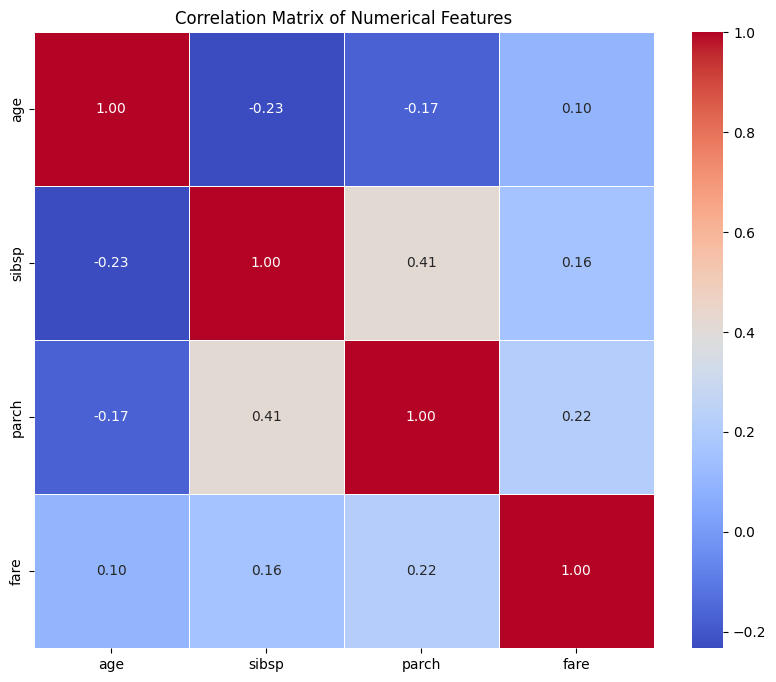

In [880]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns from titanic_copy
numerical_cols = titanic_copy.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix
correlation_matrix = titanic_copy[numerical_cols].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

When looking at the Bivariate analysis, the strongest correlation observed was between **parch** and **sibsp**, with a value of about** 0.41**, which represents a moderate positive correlation. This result is very logical, since passengers who were traveling with parents or children were also more likely to be traveling with siblings or a spouse. On the other hand, passengers who had no parents or children onboard also tended not to have siblings or spouses with them either, which explains this relationship well.

Another relationship that appeared was between **sibsp** and **age**, but this one showed a weak correlation (**0.23**). At first glance, it could seem like age might influence whether someone travels with others, but the weak value shows that being older does not necessarily mean traveling with family, and being younger also does not guarantee traveling with relatives. This helps explain why many passengers were traveling alone regardless of age.

The last notable relationship was between **fare** and **parch**, with a correlation of about **0.22**, which is also weak. This means that the ticket price was not strongly influenced by the number of parents or children traveling with a passenger. Instead, the fare is mainly determined by passenger class, which was already discussed earlier. Overall, these results show that most of the relationships between these variables are weak to moderate, meaning that many of these features behave quite independently from one another.

# Modeling


In [881]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False


## Baseline Logistic Regression

In [882]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = titanic_copy.drop('survived', axis=1)
y = titanic_copy['survived']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='category').columns

# Apply one-hot encoding to categorical features, dropping the first category to avoid multicollinearity
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean columns created by get_dummies to int, which is often required for scikit-learn models
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
# Using 'liblinear' solver which is good for small datasets and handles L1/L2 penalties
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression model: {accuracy:.4f}")

Accuracy of Logistic Regression model: 0.7989


## Outliers removal

In [883]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Remove outliers (max 5%)
num_cols = ['age', 'sibsp', 'parch', 'fare']

Q_low = titanic[num_cols].quantile(0.025)
Q_high = titanic[num_cols].quantile(0.975)

titanic_clean = titanic[~((titanic[num_cols] < Q_low) |
                          (titanic[num_cols] > Q_high)).any(axis=1)]

# 2. DROP missing values
titanic_clean = titanic_clean.dropna(subset=['age', 'fare'])

# 3. Select features and target
X = titanic_clean[['pclass', 'age', 'sibsp', 'parch', 'fare']]
y = titanic_clean['survived']

# 4. Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Build Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 6. Predictions + Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


Model Accuracy: 0.7165354330708661


In [884]:
print("Shape after cleaning:", titanic_clean.shape)


Shape after cleaning: (634, 9)


## Scaling

### Min-Max Scaler

In [885]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Re-initialize the original titanic dataset and apply previous drops to ensure 'titanic' is defined
titanic = sns.load_dataset('titanic')
titanic = titanic.drop(['deck', 'who', 'class', 'adult_male', 'embarked', 'alive'], axis=1)

# Ensure titanic_copy is defined and imputed with previous steps
titanic_copy = titanic.copy()

# Impute 'age' missing values with the median
median_age_copy = titanic_copy['age'].median()
titanic_copy['age'] = titanic_copy['age'].fillna(median_age_copy)

# Impute 'embark_town' missing values with the mode
mode_embark_town = titanic_copy['embark_town'].mode()[0]
titanic_copy['embark_town'] = titanic_copy['embark_town'].fillna(mode_embark_town)

# Define features (X) and target (y)
X = titanic_copy.drop('survived', axis=1)
y = titanic_copy['survived']

# Explicitly define categorical columns for one-hot encoding
# These columns might be of 'object', 'category', 'int64', or 'bool' dtype depending on prior steps
categorical_cols_to_encode = ['pclass', 'sex', 'embark_town', 'alone']

# Apply one-hot encoding to the explicitly defined categorical features, dropping the first category
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

# Convert any remaining boolean columns (if any) created by get_dummies to int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Create a copy of X for MinMaxScaler
X_minmax = X.copy()

# Identify numerical columns for scaling (these are the ones that are not dummy variables)
numerical_cols_to_scale = ['age', 'sibsp', 'parch', 'fare']

# Instantiate MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numerical columns in X_minmax
X_minmax[numerical_cols_to_scale] = scaler.fit_transform(X_minmax[numerical_cols_to_scale])

print("Numerical features in X_minmax scaled using MinMaxScaler.")
print(X_minmax.head())

# Split the scaled data into training and testing sets
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = train_test_split(X_minmax, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model_minmax = LogisticRegression(solver='liblinear', random_state=42)
model_minmax.fit(X_train_minmax, y_train_minmax)

# Make predictions on the scaled test set
y_pred_minmax = model_minmax.predict(X_test_minmax)

# Evaluate the model
accuracy_minmax = accuracy_score(y_test_minmax, y_pred_minmax)
print(f"Accuracy of Logistic Regression model with MinMaxScaler: {accuracy_minmax:.4f}")

Numerical features in X_minmax scaled using MinMaxScaler.
        age  sibsp  parch      fare  pclass_2  pclass_3  sex_male  \
0  0.271174  0.125    0.0  0.014151         0         1         1   
1  0.472229  0.125    0.0  0.139136         0         0         0   
2  0.321438  0.000    0.0  0.015469         0         1         0   
3  0.434531  0.125    0.0  0.103644         0         0         0   
4  0.434531  0.000    0.0  0.015713         0         1         1   

   embark_town_Queenstown  embark_town_Southampton  alone_True  
0                       0                        1           0  
1                       0                        0           0  
2                       0                        1           1  
3                       0                        1           0  
4                       0                        1           1  
Accuracy of Logistic Regression model with MinMaxScaler: 0.7989


### Standard Scaler

In [886]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Re-initialize the original titanic dataset and apply previous drops to ensure 'titanic' is defined
titanic = sns.load_dataset('titanic')
titanic = titanic.drop(['deck', 'who', 'class', 'adult_male', 'embarked', 'alive'], axis=1)

# Ensure titanic_copy is defined and imputed with previous steps
titanic_copy = titanic.copy()

# Impute 'age' missing values with the median
median_age_copy = titanic_copy['age'].median()
titanic_copy['age'] = titanic_copy['age'].fillna(median_age_copy)

# Impute 'embark_town' missing values with the mode
mode_embark_town = titanic_copy['embark_town'].mode()[0]
titanic_copy['embark_town'] = titanic_copy['embark_town'].fillna(mode_embark_town)

# Define features (X) and target (y)
X = titanic_copy.drop('survived', axis=1)
y = titanic_copy['survived']

# Explicitly define categorical columns for one-hot encoding
categorical_cols_to_encode = ['pclass', 'sex', 'embark_town', 'alone']

# Apply one-hot encoding to the explicitly defined categorical features, dropping the first category
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

# Convert any remaining boolean columns (if any) to int for compatibility with scikit-learn
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# Create a copy of X for StandardScaler
X_standard = X.copy()

# Identify numerical columns for scaling
numerical_cols_to_scale = ['age', 'sibsp', 'parch', 'fare']

# Instantiate StandardScaler
scaler_standard = StandardScaler()

# Fit and transform the numerical columns in X_standard
X_standard[numerical_cols_to_scale] = scaler_standard.fit_transform(X_standard[numerical_cols_to_scale])

print("Numerical features in X_standard scaled using StandardScaler.")
print(X_standard.head())

# Split the scaled data into training and testing sets
X_train_standard, X_test_standard, y_train_standard, y_test_standard = train_test_split(X_standard, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model_standard = LogisticRegression(solver='liblinear', random_state=42)
model_standard.fit(X_train_standard, y_train_standard)

# Make predictions on the scaled test set
y_pred_standard = model_standard.predict(X_test_standard)

# Evaluate the model
accuracy_standard = accuracy_score(y_test_standard, y_pred_standard)
print(f"Accuracy of Logistic Regression model with StandardScaler: {accuracy_standard:.4f}")

Numerical features in X_standard scaled using StandardScaler.
        age     sibsp     parch      fare  pclass_2  pclass_3  sex_male  \
0 -0.565736  0.432793 -0.473674 -0.502445         0         1         1   
1  0.663861  0.432793 -0.473674  0.786845         0         0         0   
2 -0.258337 -0.474545 -0.473674 -0.488854         0         1         0   
3  0.433312  0.432793 -0.473674  0.420730         0         0         0   
4  0.433312 -0.474545 -0.473674 -0.486337         0         1         1   

   embark_town_Queenstown  embark_town_Southampton  alone_True  
0                       0                        1           0  
1                       0                        0           0  
2                       0                        1           1  
3                       0                        1           0  
4                       0                        1           1  
Accuracy of Logistic Regression model with StandardScaler: 0.7989


## Feature Selection

### KBest

In [887]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Assuming X and y are already defined and preprocessed from the previous steps
# X contains all features after one-hot encoding and boolean to int conversion
# y contains the 'survived' target variable

# Initialize SelectKBest with f_classif scoring function and select top 3 features
k_best_selector = SelectKBest(score_func=f_classif, k=3)

# Fit the selector to the data
k_best_selector.fit(X, y)

# Get the scores for each feature
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': k_best_selector.scores_,
    'P-value': k_best_selector.pvalues_
})

# Sort features by score in descending order
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print("Feature scores (sorted):")
print(feature_scores)

# Get the names of the selected top 3 features
selected_features_mask = k_best_selector.get_support()
selected_features = X.columns[selected_features_mask]

print(f"\nSelected top {k_best_selector.k} features: {list(selected_features)}")

Feature scores (sorted):
                   Feature       Score       P-value
6                 sex_male  372.405724  1.406066e-69
5                 pclass_3  103.057599  5.510281e-23
3                     fare   63.030764  6.120189e-15
9               alone_True   38.353651  9.009490e-10
8  embark_town_Southampton   20.374460  7.223241e-06
4                 pclass_2    7.814805  5.293655e-03
2                    parch    5.963464  1.479925e-02
0                      age    3.761528  5.276069e-02
1                    sibsp    1.110572  2.922439e-01
7   embark_town_Queenstown    0.011846  9.133532e-01

Selected top 3 features: ['fare', 'pclass_3', 'sex_male']


In [888]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Feature selection
k_best_selector = SelectKBest(score_func=f_classif, k=3)
X_selected = k_best_selector.fit_transform(X, y)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(X.columns[k_best_selector.get_support()])
print("Model Accuracy:", accuracy)


Index(['fare', 'pclass_3', 'sex_male'], dtype='object')
Model Accuracy: 0.7821229050279329


In [889]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# Feature selection
k_best_selector = SelectKBest(score_func=f_classif, k=7)
X_selected = k_best_selector.fit_transform(X, y)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(X.columns[k_best_selector.get_support()])
print("Model Accuracy:", accuracy)


Index(['parch', 'fare', 'pclass_2', 'pclass_3', 'sex_male',
       'embark_town_Southampton', 'alone_True'],
      dtype='object')
Model Accuracy: 0.7932960893854749


In [890]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X and y are already defined and preprocessed from previous steps
# (one-hot encoded categorical features, boolean to int conversion)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define alpha for Lasso regularization
alpha = 0.1
# In scikit-learn, C is the inverse of regularization strength (1/alpha)
C_param = 1/alpha

# Initialize and train the Logistic Regression model with Lasso (L1) regularization
# 'liblinear' solver supports L1 penalty
lasso_model = LogisticRegression(penalty='l1', C=C_param, solver='liblinear', random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"Accuracy of Logistic Regression with Lasso (alpha={alpha}): {accuracy_lasso:.4f}")

Accuracy of Logistic Regression with Lasso (alpha=0.1): 0.7933


### LASSO

In [891]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X and y are already defined and preprocessed from previous steps
# (one-hot encoded categorical features, boolean to int conversion)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define alpha for Lasso regularization
alpha = 0.1
# In scikit-learn, C is the inverse of regularization strength (1/alpha)
C_param = 1/alpha

# Initialize and train the Logistic Regression model with Lasso (L1) regularization
# 'liblinear' solver supports L1 penalty
lasso_model = LogisticRegression(penalty='l1', C=C_param, solver='liblinear', random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"Accuracy of Logistic Regression with Lasso (alpha={alpha}): {accuracy_lasso:.4f}")
import numpy as np

selected_features = X.columns[np.abs(lasso_model.coef_[0]) > 0]
print("Selected Features:", list(selected_features))


Accuracy of Logistic Regression with Lasso (alpha=0.1): 0.7933
Selected Features: ['age', 'sibsp', 'parch', 'fare', 'pclass_2', 'pclass_3', 'sex_male', 'embark_town_Queenstown', 'embark_town_Southampton', 'alone_True']


In [892]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X and y are already defined and preprocessed from previous steps
# (one-hot encoded categorical features, boolean to int conversion)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define alpha for Lasso regularization
alpha = 10
# In scikit-learn, C is the inverse of regularization strength (1/alpha)
C_param = 1/alpha

# Initialize and train the Logistic Regression model with Lasso (L1) regularization
# 'liblinear' solver supports L1 penalty
lasso_model = LogisticRegression(penalty='l1', C=C_param, solver='liblinear', random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"Accuracy of Logistic Regression with Lasso (alpha={alpha}): {accuracy_lasso:.4f}")
import numpy as np

selected_features = X.columns[np.abs(lasso_model.coef_[0]) > 0]
print("Selected Features:", list(selected_features))


Accuracy of Logistic Regression with Lasso (alpha=10): 0.7877
Selected Features: ['age', 'sibsp', 'fare', 'pclass_2', 'pclass_3', 'sex_male']


Now moving into the modeling phase, several models were built and compared. The first model was the baseline model, which gave an accuracy of **0.7989**, meaning the model was about **80**% accurate in predicting survival. After that, **outliers were removed**, but only up to **5%** of the dataset so that the data structure would not be distorted. However, after removing outliers, the accuracy dropped to around **72%**, which was not ideal. **Scaling** was then applied using both the **Min-Max** Scaler and the **Standard Scaler**, but both approaches resulted in an accuracy of about **80%,** which was very similar to the baseline model.

Next, **SelectKBest** feature selection was used to identify the most important predictors. The value **K = 7** was chosen because it gave a strong accuracy of about **79%** while keeping the model efficient and not overly complex. The selected features were* age, fare, pclass_2, pclass_3, sex_male, embark_town_Southampton, and alone_true*. Even though using a higher K gave similar accuracy, K = 7 was preferred since it achieved nearly the same performance with fewer variables, it's **cheaper**.

Finally, Logistic Regression with **LASSO regularization** was applied using **alpha = 0.1**, which also produced an accuracy of about **79%**. The features selected by LASSO were very similar and included *age, sibsp, parch, fare, pclass_2, pclass_3, sex_male, embark_town_Southampton, embark_town_Queenstown, and alone_true*. Overall, these results show that multiple modeling approaches produced very similar performance, with accuracy consistently around *79–80%*, which indicates that the prediction task is reasonably stable across different methods.

## Decision Trees

In [893]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming X_standard and y are already defined from previous StandardScaler steps

# Split the data (X_standard and y) into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_standard, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train_dt, y_train_dt)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test_dt)

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print(f"Accuracy of Decision Tree model on StandardScaler data: {accuracy_dt:.4f}")

Accuracy of Decision Tree model on StandardScaler data: 0.7430


In [894]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree model (corrected)
tree = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=10,
    max_leaf_nodes=15,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini",   # classification criterion
    min_impurity_decrease=0.0
)

tree.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Feature Importances
importance = tree.feature_importances_
for i, feature_name in enumerate(X.columns):
    print(f"{feature_name}: {importance[i]}")


Decision Tree Accuracy: 0.8100558659217877
age: 0.07303125386361396
sibsp: 0.015604691949323412
parch: 0.0
fare: 0.15039273435404724
pclass_2: 0.01203741443730735
pclass_3: 0.16090461302709405
sex_male: 0.5742580302392595
embark_town_Queenstown: 0.0
embark_town_Southampton: 0.013771262129354613
alone_True: 0.0


In [895]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIXED DECISION TREE ---
tree = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=10,
    max_leaf_nodes=15,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini",
    min_impurity_decrease=0.0
)

tree.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.8100558659217877


In [896]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIXED DECISION TREE ---
tree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=5,
    max_leaf_nodes=17,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini",
    min_impurity_decrease=0.0
)

tree.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.8491620111731844


## Naive Bayes

In [897]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets (80/20 split)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred_gnb = gnb_model.predict(X_test_gnb)

# Calculate the accuracy
accuracy_gnb = accuracy_score(y_test_gnb, y_pred_gnb)

# Print the accuracy
print(f"Accuracy of Gaussian Naive Bayes model: {accuracy_gnb:.4f}")

Accuracy of Gaussian Naive Bayes model: 0.7933


In [898]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# Create a copy of X for Bernoulli Naive Bayes
X_bernoulli = X.copy()

# Binarize 'age' and 'fare' by their medians
median_age = X_bernoulli['age'].median()
median_fare = X_bernoulli['fare'].median()
X_bernoulli['age_binarized'] = (X_bernoulli['age'] > median_age).astype(int)
X_bernoulli['fare_binarized'] = (X_bernoulli['fare'] > median_fare).astype(int)

# Binarize 'sibsp' and 'parch' by checking if values are greater than 0
X_bernoulli['sibsp_binarized'] = (X_bernoulli['sibsp'] > 0).astype(int)
X_bernoulli['parch_binarized'] = (X_bernoulli['parch'] > 0).astype(int)

# Drop original continuous columns
X_bernoulli = X_bernoulli.drop(columns=['age', 'sibsp', 'parch', 'fare'])

# Split the binarized data into training and testing sets (80/20 split)
X_train_bnb, X_test_bnb, y_train_bnb, y_test_bnb = train_test_split(X_bernoulli, y, test_size=0.2, random_state=42)

# Initialize the Bernoulli Naive Bayes model
bnb_model = BernoulliNB()

# Train the model
bnb_model.fit(X_train_bnb, y_train_bnb)

# Make predictions on the test set
y_pred_bnb = bnb_model.predict(X_test_bnb)

# Calculate the accuracy
accuracy_bnb = accuracy_score(y_test_bnb, y_pred_bnb)

# Print the accuracy
print(f"Accuracy of Bernoulli Naive Bayes model: {accuracy_bnb:.4f}")

Accuracy of Bernoulli Naive Bayes model: 0.7486


In [899]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score

# Create a copy of X for Categorical Naive Bayes
X_categorical = X.copy()

# Identify numerical columns for discretization
numerical_cols_to_discretize = ['age', 'sibsp', 'parch', 'fare']

# Initialize KBinsDiscretizer for uniform strategy
# n_bins can be adjusted, but a default of 5 is often reasonable for initial exploration
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform', subsample=None, random_state=42)

# Apply discretization to numerical columns
X_categorical[numerical_cols_to_discretize] = discretizer.fit_transform(X_categorical[numerical_cols_to_discretize])

# Split the discretized data into training and testing sets (80/20 split)
X_train_cnb, X_test_cnb, y_train_cnb, y_test_cnb = train_test_split(X_categorical, y, test_size=0.2, random_state=42)

# Initialize the Categorical Naive Bayes model
cnb_model = CategoricalNB()

# Train the model
cnb_model.fit(X_train_cnb, y_train_cnb)

# Make predictions on the test set
y_pred_cnb = cnb_model.predict(X_test_cnb)

# Calculate the accuracy
accuracy_cnb = accuracy_score(y_test_cnb, y_pred_cnb)

# Print the accuracy
print(f"Accuracy of Categorical Naive Bayes model: {accuracy_cnb:.4f}")

print("\n--- Naive Bayes Model Accuracies ---")
print(f"Gaussian Naive Bayes: {accuracy_gnb:.4f}")
print(f"Bernoulli Naive Bayes: {accuracy_bnb:.4f}")
print(f"Categorical Naive Bayes: {accuracy_cnb:.4f}")

Accuracy of Categorical Naive Bayes model: 0.7877

--- Naive Bayes Model Accuracies ---
Gaussian Naive Bayes: 0.7933
Bernoulli Naive Bayes: 0.7486
Categorical Naive Bayes: 0.7877


In [900]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets (80/20 split)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred_gnb = gnb_model.predict(X_test_gnb)

# Calculate the accuracy
accuracy_gnb = accuracy_score(y_test_gnb, y_pred_gnb)

# Print the accuracy
print(f"Accuracy of Gaussian Naive Bayes model: {accuracy_gnb:.4f}")

Accuracy of Gaussian Naive Bayes model: 0.7933


In [901]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

#  Standard Scaling FIRST
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

#  Split (80/20)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X_standard, y, test_size=0.2, random_state=42
)

# YOU change this value manually each time
var_smoothing = 1e-7

# Gaussian Naive Bayes model
gnb_model = GaussianNB(var_smoothing=var_smoothing)
gnb_model.fit(X_train_gnb, y_train_gnb)

y_pred_gnb = gnb_model.predict(X_test_gnb)
accuracy = accuracy_score(y_test_gnb, y_pred_gnb)

print(f"GaussianNB Accuracy (var_smoothing = {var_smoothing}): {accuracy:.4f}")

GaussianNB Accuracy (var_smoothing = 1e-07): 0.7933


In [902]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

#  Standard Scaling FIRST
scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

#  Split (80/20)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X_standard, y, test_size=0.2, random_state=42
)

#
var_smoothing = 1e-1

gnb_model = GaussianNB(var_smoothing=var_smoothing)
gnb_model.fit(X_train_gnb, y_train_gnb)

y_pred_gnb = gnb_model.predict(X_test_gnb)
accuracy = accuracy_score(y_test_gnb, y_pred_gnb)

print(f"GaussianNB Accuracy (var_smoothing = {var_smoothing}): {accuracy:.4f}")

GaussianNB Accuracy (var_smoothing = 0.1): 0.7989


In [903]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

#  Split (80/20)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X_standard, y, test_size=0.2, random_state=42
)

var_smoothing = 1e-3

#  Gaussian Naive Bayes model
gnb_model = GaussianNB(var_smoothing=var_smoothing)
gnb_model.fit(X_train_gnb, y_train_gnb)

#  Predictions & Accuracy
y_pred_gnb = gnb_model.predict(X_test_gnb)
accuracy = accuracy_score(y_test_gnb, y_pred_gnb)

print(f"GaussianNB Accuracy (var_smoothing = {var_smoothing}): {accuracy:.4f}")

GaussianNB Accuracy (var_smoothing = 0.001): 0.7933


#### Trees Combinations

In [904]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_standard, y, test_size=0.2, random_state=42)

# Initialize the KNeighborsClassifier model with n_neighbors=7
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn_model.fit(X_train_knn, y_train_knn)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_knn)

# Calculate and print the accuracy
accuracy_knn = accuracy_score(y_test_knn, y_pred_knn)
print(f"Accuracy of KNN model: {accuracy_knn:.4f}")

Accuracy of KNN model: 0.8268


In [905]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Re-split the X_standard and y data for the Decision Tree, ensuring consistency with KNN split
X_train_dt_re, X_test_dt_re, y_train_dt_re, y_test_dt_re = train_test_split(X_standard, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier with the best parameters found previously
# The best parameters were: max_depth=7, min_samples_leaf=5, max_leaf_nodes=17
dtc_model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=5,
    max_leaf_nodes=17,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini",
    min_impurity_decrease=0.0
)

# Train the Decision Tree model on the standard scaled training data
dtc_model.fit(X_train_dt_re, y_train_dt_re)

print("Decision Tree Classifier re-trained on X_standard.")

Decision Tree Classifier re-trained on X_standard.


In [906]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# -------------------------
# 1. Train/Test Split (80/20)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_standard, y, test_size=0.2, random_state=42
)

# -------------------------
# 2. Decision Tree Model
# -------------------------
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

# -------------------------
# 3. LASSO Logistic Regression (alpha = 10)
# -------------------------
alpha = 10
C_param = 1 / alpha

lasso_model = LogisticRegression(
    penalty='l1',
    C=C_param,
    solver='liblinear',
    random_state=42
)
lasso_model.fit(X_train, y_train)

# -------------------------
# 4. Voting Ensemble (DT + LASSO)
# -------------------------
voting_clf = VotingClassifier(
    estimators=[
        ('lasso', lasso_model),
        ('dtc', dtc_model)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)

# -------------------------
# 5. Accuracy
# -------------------------
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Ensemble Accuracy (DT + LASSO, alpha=10): {accuracy:.4f}")

Ensemble Accuracy (DT + LASSO, alpha=10): 0.7486


 On to the Decision Tree model, a baseline version was first built and it gave an accuracy of about **74%**. After that, the model was tuned using **hyperparameters**, which significantly improved the performance and pushed the accuracy up to around **81%**, which was already higher than most of the previous models. The tuning process continued to find the best possible configuration, and the highest accuracy achieved with the Decision Tree was about 84.91%, about 85% which became the best performance across all models tested.

After that, the focus shifted to **Naive Bayes models**. The baseline Naive Bayes model produced an accuracy of about **79.33%**, which was already quite strong. Three different versions of Naive Bayes were then tested: **Bernoulli Naive Bayes**, **Categorical Naive Bayes**, and **Gaussian Naive Bayes**. Out of the three, the **Gaussian Naive Bayes** model consistently performed the best, with an accuracy of around **79.33%**, so it was selected for further tuning. Even after tuning, the **highest** accuracy that could be achieved with Gaussian Naive Bayes was about **79.89%**, which remained very close to the baseline score.

Other models such as KBest-selected Logistic Regression and LASSO-tuned Logistic Regression were also tested alongside the tuned Decision Tree, but even with optimization, they stayed below The 85% accuracy achieved by the tuned Decision Tree. Although some of these models reached relatively high accuracies of about 83%, none were able to outperform the final tuned Decision Tree model.


# Model Evaluation

## Confusion Matrices

In [907]:
# Model 1: Decision Tree Classifier

In [908]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- FIXED DECISION TREE ---
tree = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=5,
    max_leaf_nodes=17,
    random_state=42,
    max_features=None,
    splitter="best",
    criterion="gini",
    min_impurity_decrease=0.0
)

tree.fit(X_train, y_train)

# Predictions & Accuracy
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.8491620111731844


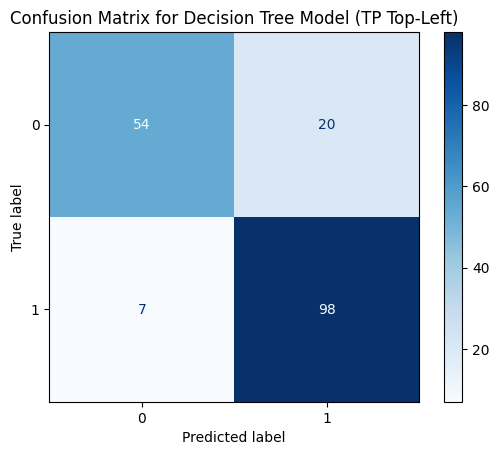

In [909]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are available from the previous Decision Tree model
#  Only change: force label order so TP is top-left
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree Model (TP Top-Left)')
plt.show()


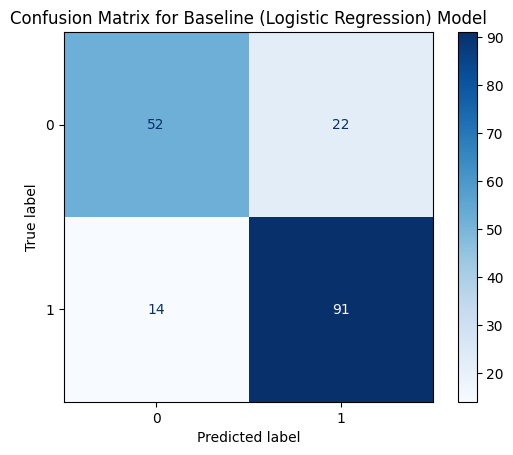

Accuracy of the Baseline (Logistic Regression) Model: 0.7989


In [910]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# ONLY CHANGE IS THIS LINE
cm_baseline = confusion_matrix(y_test_standard, y_pred_standard, labels=[1, 0])

disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline)
disp_baseline.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Baseline (Logistic Regression) Model')
plt.show()

accuracy_baseline = accuracy_score(y_test_standard, y_pred_standard)
print(f"Accuracy of the Baseline (Logistic Regression) Model: {accuracy_baseline:.4f}")


In [911]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Ensure X is correctly prepared (one-hot encoded and boolean to int) before scaling
# If X is not already one-hot encoded, re-apply it here.
# Based on the kernel state, X still contains object type columns like 'sex' and 'embark_town'.

# Make a copy of X to ensure original X is not modified if it's used elsewhere unencoded
X_processed = X.copy()

# Identify categorical columns that might still be present as objects/categories
categorical_cols_in_X = X_processed.select_dtypes(include=['object', 'category', 'bool']).columns

# Apply one-hot encoding to these categorical features, dropping the first category to avoid multicollinearity
# Ensure 'alone' is treated correctly if it's still boolean and not yet handled
X_processed = pd.get_dummies(X_processed, columns=categorical_cols_in_X, drop_first=True)

# Convert any remaining boolean columns (if any) created by get_dummies to int
for col in X_processed.columns:
    if X_processed[col].dtype == 'bool':
        X_processed[col] = X_processed[col].astype(int)

# Standard Scaling FIRST
scaler = StandardScaler()
X_standard_scaled = scaler.fit_transform(X_processed) # Use the processed X

# Split (80/20)
X_train_gnb, X_test_gnb, y_train_gnb, y_test_gnb = train_test_split(
    X_standard_scaled, y, test_size=0.2, random_state=42
)

var_smoothing = 1e-1

#  Gaussian Naive Bayes model
gnb_model = GaussianNB(var_smoothing=var_smoothing)
gnb_model.fit(X_train_gnb, y_train_gnb)

# Predictions & Accuracy
y_pred_gnb = gnb_model.predict(X_test_gnb)
accuracy = accuracy_score(y_test_gnb, y_pred_gnb)

print(f"GaussianNB Accuracy (var_smoothing = {var_smoothing}): {accuracy:.4f}")

GaussianNB Accuracy (var_smoothing = 0.1): 0.7989


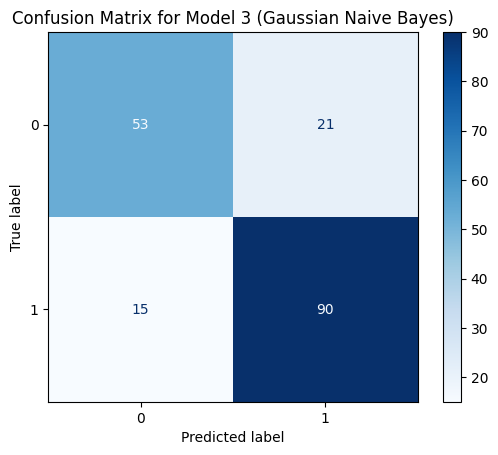

In [912]:
# Model 3: Gaussian Naive Bayes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#  ONLY CHANGE IS THIS LINE
cm_gnb = confusion_matrix(y_test_gnb, y_pred_gnb, labels=[1, 0])

disp_gnb = ConfusionMatrixDisplay(confusion_matrix=cm_gnb)
disp_gnb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Model 3 (Gaussian Naive Bayes)')
plt.show()


Now moving on to looking at the models in more **depth**, the top three models that were selected were the tuned Decision Tree, the baseline Logistic Regression model, and the Gaussian Naive Bayes model. The Decision Tree was chosen because it produced the highest accuracy at about 85%, making it the strongest model in terms of raw performance. The baseline Logistic Regression model was kept because even after scaling and multiple tuning attempts, its accuracy consistently returned to about 79.89%, about 80% accuracy. The third model selected was the Gaussian Naive Bayes, which also achieved an accuracy of about 79.89%. Even though these two models gave the **same accuracy score**, the actual **predictions were not the same**, which is why a **deeper evaluation** was necessary.

To better understand the behavior of each model, **Confusion matrices** were used to analyze how each one performed in detail. The main objective here was to select a model that had **high true positives** and **high true negatives**, meaning the model correctly predicts both survivors as survivors and non-survivors as non-survivors. At the same time, having a **low false positive rate** was **very** important. A false positive in this case means predicting that someone survived when they actually did not, which could lead to **false hope for families** searching for relatives. While **false negatives** are also important, the goal was to **avoid giving incorrect positive survival** predictions because of the emotional and practical consequences this could have.

### Matrices Insights


====== FINAL MODEL COMPARISON ======
1) Decision Tree Accuracy: 0.8492
2) Logistic Regression (Baseline): 0.7989
3) Gaussian Naive Bayes: 0.7989


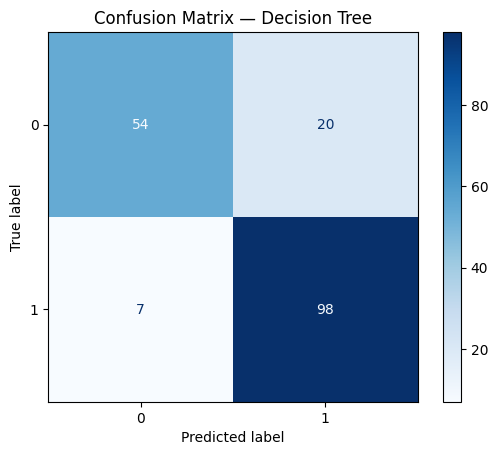

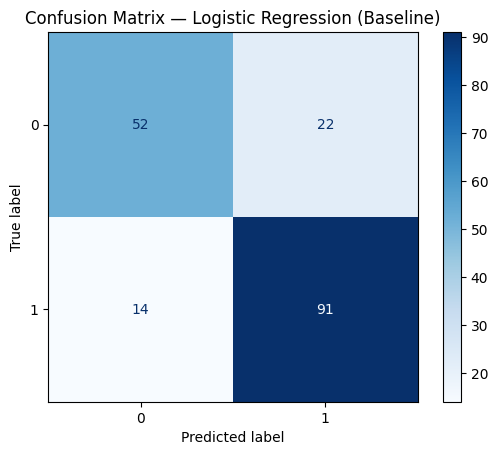

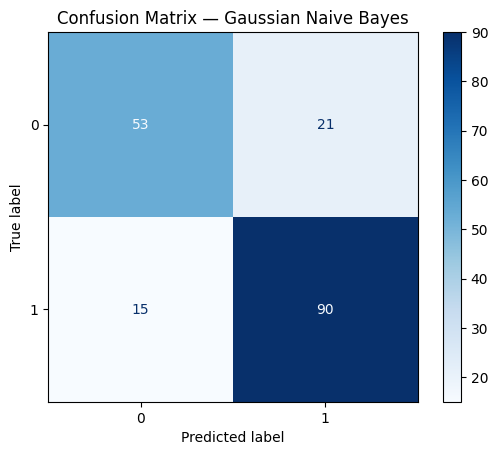

In [913]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# -------------------------------
# MODEL 1 — DECISION TREE
# -------------------------------
cm_tree = confusion_matrix(y_test, y_pred, labels=[1, 0])
acc_tree = accuracy_score(y_test, y_pred)

# -------------------------------
# MODEL 2 — LOGISTIC REGRESSION (BASELINE - NO SCALING)
# -------------------------------
cm_baseline = confusion_matrix(y_test_standard, y_pred_standard, labels=[1, 0])
acc_baseline = accuracy_score(y_test_standard, y_pred_standard)

# -------------------------------
# MODEL 3 — GAUSSIAN NAIVE BAYES
# -------------------------------
cm_gnb = confusion_matrix(y_test_gnb, y_pred_gnb, labels=[1, 0])
acc_gnb = accuracy_score(y_test_gnb, y_pred_gnb)


# -------------------------------
# PRINT ALL ACCURACIES TOGETHER
# -------------------------------
print("\n====== FINAL MODEL COMPARISON ======")
print(f"1) Decision Tree Accuracy: {acc_tree:.4f}")
print(f"2) Logistic Regression (Baseline): {acc_baseline:.4f}")
print(f"3) Gaussian Naive Bayes: {acc_gnb:.4f}")


# -------------------------------
# DISPLAY ALL CONFUSION MATRICES (TP TOP-LEFT)
# -------------------------------
models_cm = [
    ("Decision Tree", cm_tree),
    ("Logistic Regression (Baseline)", cm_baseline),
    ("Gaussian Naive Bayes", cm_gnb)
]

for title, cm in models_cm:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {title}")
    plt.show()


Looking at the overall performance of the three selected models, the **Decision Tree** clearly **stands out**. It produces the **highest True Positives**, meaning it correctly predicts the largest number of actual survivors. At the same time, it also gives the **lowest False Positives**, which was one of the **most important criteria in this project**. A false positive here means predicting that someone survived when they actually did not, which could create **false hope for families**. In addition to that, the **True Negatives** are also **very high**, with 98 correct predictions of non-survivors, which shows that the model is also very reliable at identifying passengers who did not survive. Overall, this makes the Decision Tree a very **strong** and **balanced model**.

For the other two models, even though their accuracy scores were close to 80%, they showed nearly **double or even more False Positives** compared to the Decision Tree. This is not ideal for this type of application, since predicting survival incorrectly is **more harmful** than simply missing a survivor. This difference in False Positives is one of the main reasons why the Decision Tree was preferred over the other models.

## Perfomance Evaluation (Accuracy , Precision, Recall, F1-score)

**Formulas**


Accuracy = (TP + TN) / (TP + TN + FP + FN)


Precision = TP / (TP + FP)


Recall = TP / (TP + FN)


F1-Score = 2 * (Precision * Recall) / (Precision + Recall)  

In [914]:
# Decision Trees
Accuracy = (54 + 98) / (54 + 98 + 7 + 20)
Precision = 54 / (54 + 7)
Recall = 54 / (54 + 20)
F1_Score = 2 * (Precision * Recall) / (Precision + Recall)

print(f"Accuracy    : {Accuracy:.4f}")
print(f"Precision   : {Precision:.4f}")
print(f"Recall      : {Recall:.4f}")
print(f"F1-Score    : {F1_Score:.4f}")

Accuracy    : 0.8492
Precision   : 0.8852
Recall      : 0.7297
F1-Score    : 0.8000


In [915]:
# Logistic Regression
Accuracy = (52 + 91) / (52 + 91 + 14 + 22)
Precision = 52 / (52 + 14)
Recall = 52 / (52 + 22)
F1_Score = 2 * (Precision * Recall) / (Precision + Recall)

print(f"Accuracy    : {Accuracy:.4f}")
print(f"Precision   : {Precision:.4f}")
print(f"Recall      : {Recall:.4f}")
print(f"F1-Score    : {F1_Score:.4f}")

Accuracy    : 0.7989
Precision   : 0.7879
Recall      : 0.7027
F1-Score    : 0.7429


In [916]:
# Naive Bayes ( GaussianNB)
Accuracy = (53 + 90) / (53 + 90 + 15 + 21)
Precision = 53 / (53 + 15)
Recall = 53 / (53 + 21)
F1_Score = 2 * (Precision * Recall) / (Precision + Recall)

print(f"Accuracy    : {Accuracy:.4f}")
print(f"Precision   : {Precision:.4f}")
print(f"Recall      : {Recall:.4f}")
print(f"F1-Score    : {F1_Score:.4f}")

Accuracy    : 0.7989
Precision   : 0.7794
Recall      : 0.7162
F1-Score    : 0.7465


Now looking at the final performance metrics after all calculations, the Decision Tree model clearly performs the best overall. Its accuracy is** 0.8492**, which means it **correctly predicts about 85% of the outcomes**, which is very strong. The **precision** is about **88%**, meaning that when the model predicts someone has **survived**, it is **correct** most of the time. This is especially important because it keeps the false positives low, meaning it rarely predicts survival when the person actually did not survive. The **recall** is about **72.97%**, which means that out of all the real survivors, the model successfully identifies about **73% **of them, which is still very good. The **F1-score** is around **80%**, showing that there is a** strong balance** between precision and recall, and overall the model is very reliable and well balanced.

Now looking at the Logistic Regression model, its **accuracy** is about **79.89%**, meaning nearly 80% of the predictions are correct, which is also very solid. The precision is about **78.79%**, showing that when it predicts survival, it is correct most of the time. For the Naive Bayes model, the precision is about **77.94%**, which is slightly lower than Logistic Regression. This shows that Logistic Regression is slightly **better** at predicting survivors correctly than** Naive Bayes**, but both still perform fairly well.

When comparing recall, the **Logistic Regression** model has a **Recall** of **0.7027**, while **Naive Bayes** has a **recall** of 0.7162. This means that Naive Bayes is slightly **better at catching more of the actual survivors**, but the difference between the two is very small. Looking at the F1-scores, Logistic Regression has an F1-score of 0.7429, while Naive Bayes has an F1-score of 0.7465, which again shows that their performances are very close and **fairly balanced**.


##  ROC

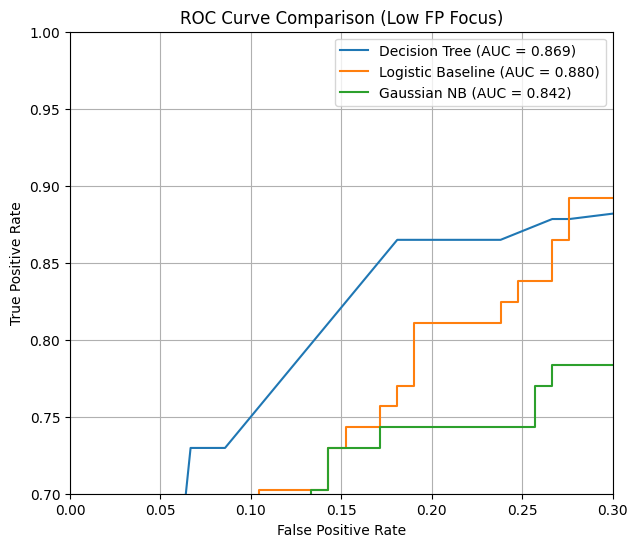

In [917]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Get probabilities (REQUIRED for ROC) ---
y_prob_tree = tree.predict_proba(X_test)[:, 1]
y_prob_log  = model_standard.predict_proba(X_test_standard)[:, 1]
y_prob_gnb  = gnb_model.predict_proba(X_test_gnb)[:, 1]

# --- ROC Curves ---
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_log,  tpr_log,  _ = roc_curve(y_test_standard, y_prob_log)
fpr_gnb,  tpr_gnb,  _ = roc_curve(y_test_gnb, y_prob_gnb)

# --- AUC Scores ---
auc_tree = auc(fpr_tree, tpr_tree)
auc_log  = auc(fpr_log,  tpr_log)
auc_gnb  = auc(fpr_gnb,  tpr_gnb)

# --- Plot ROC ---
plt.figure(figsize=(7, 6))

plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_log,  tpr_log,  label=f"Logistic Baseline (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb,  tpr_gnb,  label=f"Gaussian NB (AUC = {auc_gnb:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], "k--")

#  This axis setup is EXACTLY what your professor meant
plt.xlim([0, 0.3])   # LOW FALSE POSITIVE REGION (what you care about)
plt.ylim([0.7, 1.0]) # HIGH TRUE POSITIVE REGION

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Low FP Focus)")
plt.legend()
plt.grid()
plt.show()


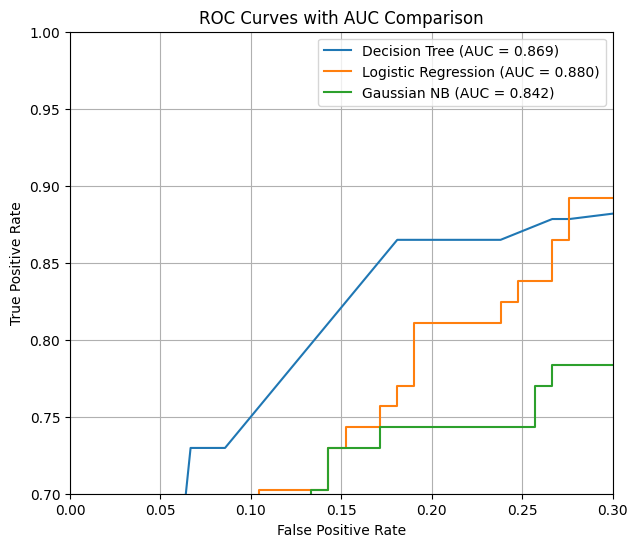

In [918]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities (REQUIRED)
y_prob_tree = tree.predict_proba(X_test)[:,1]
y_prob_log  = model_standard.predict_proba(X_test_standard)[:,1]
y_prob_gnb  = gnb_model.predict_proba(X_test_gnb)[:,1]

# ROC Curves
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_log,  tpr_log,  _ = roc_curve(y_test_standard, y_prob_log)
fpr_gnb,  tpr_gnb,  _ = roc_curve(y_test_gnb, y_prob_gnb)

# AUC VALUES
auc_tree = auc(fpr_tree, tpr_tree)
auc_log  = auc(fpr_log,  tpr_log)
auc_gnb  = auc(fpr_gnb,  tpr_gnb)

# PLOT
plt.figure(figsize=(7,6))

plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_log,  tpr_log,  label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb,  tpr_gnb,  label=f"Gaussian NB (AUC = {auc_gnb:.3f})")

plt.plot([0,1], [0,1], "k--")

# Focus on LOW FP & HIGH TP
plt.xlim(0, 0.3)
plt.ylim(0.7, 1.0)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with AUC Comparison")
plt.legend()
plt.grid()
plt.show()


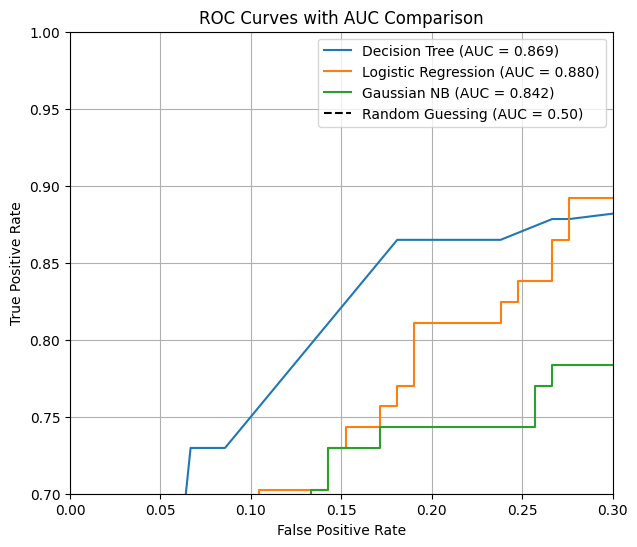

In [919]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Get probabilities ---
y_prob_tree = tree.predict_proba(X_test)[:,1]
y_prob_log  = model_standard.predict_proba(X_test_standard)[:,1]
y_prob_gnb  = gnb_model.predict_proba(X_test_gnb)[:,1]

# --- ROC Curves ---
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_log,  tpr_log,  _ = roc_curve(y_test_standard, y_prob_log)
fpr_gnb,  tpr_gnb,  _ = roc_curve(y_test_gnb, y_prob_gnb)

# --- AUC Scores ---
auc_tree = auc(fpr_tree, tpr_tree)
auc_log  = auc(fpr_log,  tpr_log)
auc_gnb  = auc(fpr_gnb,  tpr_gnb)

# --- Plot ROC ---
plt.figure(figsize=(7,6))

plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_log,  tpr_log,  label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_gnb,  tpr_gnb,  label=f"Gaussian NB (AUC = {auc_gnb:.3f})")

# RANDOM GUESSING LINE
plt.plot([0,1], [0,1], "k--", label="Random Guessing (AUC = 0.50)")

# Focus on LOW FP & HIGH TP
plt.xlim(0, 0.3)
plt.ylim(0.7, 1.0)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves with AUC Comparison")
plt.legend()
plt.grid()
plt.show()


# Business Insight

ROC curves were used to compare the models **visually**, and they clearly confirmed everything that was observed earlier with the metrics. From the graph, the Decision Tree stands out again as the best model, since it shows the **lowest false positive rate**, which was one of the **most important goals** of this project. At the same time, it also maintains a **high true positive rate**, meaning it correctly identifies a large portion of real survivors. This confirms that the Decision Tree is not only accurate but also **very well balanced** in how it handles both **survival** and **non-survival** predictions.

More specifically, the Decision Tree correctly predicted about **88% of the people who actually survived**, which is a very strong and trustworthy score. At the same time, it **only produced 7 false positives**, meaning it rarely predicted survival when the person had actually died. This is extremely important in a real-world setting, because predicting that someone survived when they did not can create false hope for families, which can be **emotionally devastating**. On the other side, it also keeps the false negatives relatively low, meaning it does not often predict death when the person actually survived, which helps **avoid unnecessary emotional distress**.

Because this model performs well on both total positive and total negative predictions, while also keeping false positives and false negatives as low as possible, the **Decision Tree Model** is clearly the **most reliable** and **ethical choice** for this prediction task. For all of these reasons, the final model selected for this project is the tuned Decision Tree model.

## Conclusion

Overall, the model that best balances performance and real-world usefulness is the Decision Tree. While multiple models achieved strong accuracy, the Decision Tree stands out not only for its predictive power, but also for its **interpretability**, which is critical for non-technical decision-makers. Its structure makes it easy to understand which **factors most influence survival**, allowing executives to trust and explain the model’s decisions. In addition, the model is scalable, meaning it can be efficiently **applied to larger datasets** or **adapted to similar real-world prediction problems**. This makes the Decision Tree the most suitable choice for **executives**, **analysts**, and **operational teams**, who require both strong performance and clear, actionable insights to support data-driven decision-making.